# 02 — Architecture JEPA hiérarchique (POC trajectoires)

Objectif : une **preuve de concept** — un JEPA capte-t-il la structure des trajectoires de consommateurs ? On prédit, **dans l'espace des représentations**, le *prochain chunk* de films.

## Le schéma

```
Séquence user ──► chunks de K=5 films (ensembles, ordre interne ignoré)
                   [f1..f5] [f6..f10] [f11..f15] ...
                      │        │         │
  Encodeur de chunk C (dédié, token [CHUNK])   ← mêmes poids partagés
                      ▼        ▼         ▼
                     c1       c2        c3      ← vecteurs de chunk
                      │        │         │
     Transformer temporel CAUSAL f_θ (sur la suite de chunks)
                      ▼        ▼         ▼
                     h1       h2        h3      ← état de contexte
                      │        │
               MLP prédicteur g
                      ▼        ▼
                    ẑ1  →     ẑ2   ...          ← prédiction du chunk SUIVANT
                      ║        ║
                  z2=Cξ(c2)  z3=Cξ(c3)         ← cible : EMA de C, stop-grad
```

**Perte** = `1 - cosine(ẑ_t, z_{t+1})` (invariance) **+ VICReg** (variance + covariance) pour interdire l'**effondrement**.

> Point clé : l'encodeur de chunk sert des DEUX côtés (contexte *et* cible via EMA). Il reçoit donc du gradient côté contexte → l'EMA est valide, et le bootstrapping est résolu.

In [ ]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

from src.data_prep import load_all
from src.data_jepa import JepaTrainDataset, collate_train, to_chunks, CHUNK_SIZE
from src.jepa import TrajectoryJEPA, jepa_loss

torch.manual_seed(0)
DEVICE = "mps" if torch.backends.mps.is_available() else "cpu"
print("device:", DEVICE)

device: mps


## 1 — Données prêtes (issues du notebook 01)

In [2]:
sequences, genome, maps = load_all()
print(f"{len(sequences):,} trajectoires | {maps.n_items:,} films | genome {genome.shape}")

138,493 trajectoires | 10,345 films | genome (10346, 1128)


## 2 — Découpage en chunks

On coupe chaque séquence en chunks pleins de K=5 (le reste < 5 est ignoré). Illustration sur un user, avec les titres.

In [3]:
items0 = sequences.iloc[0]["items"]
ch0 = to_chunks(items0, CHUNK_SIZE)
print(f"User {sequences.iloc[0].userId}: {len(items0)} films -> {len(ch0)} chunks de {CHUNK_SIZE}\n")
for j, chunk in enumerate(ch0[:3]):
    print(f"  chunk {j}:")
    for idx in chunk:
        print("     -", maps.titles[int(idx)])

User 1: 174 films -> 34 chunks de 5

  chunk 0:
     - Rumble in the Bronx (Hont faan kui) (1995)
     - Rob Roy (1995)
     - What's Eating Gilbert Grape (1993)
     - Dragonheart (1996)
     - Wizard of Oz, The (1939)
  chunk 1:
     - 2001: A Space Odyssey (1968)
     - Fish Called Wanda, A (1988)
     - Alien (1979)
     - Psycho (1960)
     - Dead Poets Society (1989)
  chunk 2:
     - Shining, The (1980)
     - Young Frankenstein (1974)
     - Butch Cassidy and the Sundance Kid (1969)
     - Die Hard 2 (1990)
     - Star Trek II: The Wrath of Khan (1982)


In [4]:
# Dataset d'entraînement : contexte = chunks[:-2] (val/test tenus à l'écart)
train_ds = JepaTrainDataset(sequences, K=CHUNK_SIZE, min_chunks=4)
print(f"users retenus (>= 4 chunks) : {len(train_ds):,} ({len(train_ds)/len(sequences)*100:.1f} %)")

loader = DataLoader(train_ds, batch_size=32, shuffle=True, collate_fn=collate_train)
chunks, mask = next(iter(loader))
print("batch chunks:", tuple(chunks.shape), "(B, M, K)  | mask:", tuple(mask.shape),
      "| chunks réels:", int(mask.sum()))

users retenus (>= 4 chunks) : 138,185 (99.8 %)
batch chunks: (32, 98, 5) (B, M, K)  | mask: (32, 98) | chunks réels: 862


## 3 — Le modèle

Petit (d=128, 4 têtes, 2 couches par Transformer). ~2,3M paramètres entraînables.

In [5]:
model = TrajectoryJEPA(maps.n_items, genome, d_model=128, nhead=4,
                       chunk_layers=2, temporal_layers=2, ema=0.996).to(DEVICE)
n = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"paramètres entraînables : {n/1e6:.2f}M")
print("cible EMA (non entraînée) :",
      sum(p.numel() for p in model.target_chunk.parameters())/1e6, "M de params gelés")

paramètres entraînables : 2.34M
cible EMA (non entraînée) : 1.865728 M de params gelés


## 4 — Passe avant : les trois représentations

- `c`  = chunks encodés côté **online** (avec gradient)
- `z`  = chunks encodés côté **cible EMA** (stop-grad)
- `ẑ`  = prédiction : à la position t, `ẑ_t` vise `z_{t+1}` (le prochain chunk)

In [6]:
chunks, mask = chunks.to(DEVICE), mask.to(DEVICE)
c, z, zhat = model(chunks, mask)
print("c   (online) :", tuple(c.shape))
print("z   (cible)  :", tuple(z.shape), "| requires_grad =", z.requires_grad)
print("zhat (prédit):", tuple(zhat.shape))

c   (online) : (32, 98, 128)
z   (cible)  : (32, 98, 128) | requires_grad = False
zhat (prédit): (32, 98, 128)


## 5 — La perte, décomposée

- **inv** : `1 - cosine(ẑ_t, z_{t+1})` — la vraie tâche (prédire la représentation du prochain chunk)
- **var** : terme VICReg qui force chaque dimension à garder de la variance (anti-effondrement)
- **cov** : terme VICReg qui décorrèle les dimensions
- **pred_std** : écart-type moyen des prédictions — s'il tend vers 0, c'est l'**effondrement**

In [7]:
loss, logs = jepa_loss(c, z, zhat, mask)
for k, v in logs.items():
    print(f"  {k:10s}: {v:.4f}" if isinstance(v, float) else f"  {k:10s}: {v}")

  loss      : 40.6997
  inv       : 0.9839
  var       : 0.6414
  cov       : 0.0667
  n_pairs   : 830
  pred_std  : 0.2336
  tgt_std   : 0.4710


## 6 — Mini-entraînement de contrôle (sanity check)

Pas le vrai entraînement — juste ~150 pas pour vérifier deux choses :
1. la perte **descend** (le modèle apprend à prédire les chunks) ;
2. `pred_std` **ne s'effondre pas** vers 0 (VICReg tient).

> Si `pred_std` chutait vers 0 pendant que la loss chute, ce serait le signe classique de l'effondrement : le modèle triche en prédisant un vecteur constant.

In [8]:
opt = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
hist = {"loss": [], "inv": [], "pred_std": [], "tgt_std": []}

model.train()
step = 0
for chunks, mask in loader:
    chunks, mask = chunks.to(DEVICE), mask.to(DEVICE)
    c, z, zhat = model(chunks, mask)
    loss, logs = jepa_loss(c, z, zhat, mask)
    opt.zero_grad(); loss.backward(); opt.step()
    model.update_target()                       # mise à jour EMA de la cible
    for k in hist:
        hist[k].append(logs[k])
    step += 1
    if step % 30 == 0:
        print(f"step {step:3d} | loss {logs['loss']:.3f} | inv {logs['inv']:.3f} | "
              f"pred_std {logs['pred_std']:.3f}")
    if step >= 150:
        break

step  30 | loss 11.134 | inv 0.380 | pred_std 1.019


step  60 | loss 5.178 | inv 0.166 | pred_std 1.016


step  90 | loss 3.244 | inv 0.096 | pred_std 1.039


step 120 | loss 2.556 | inv 0.066 | pred_std 1.030


step 150 | loss 2.096 | inv 0.053 | pred_std 1.061


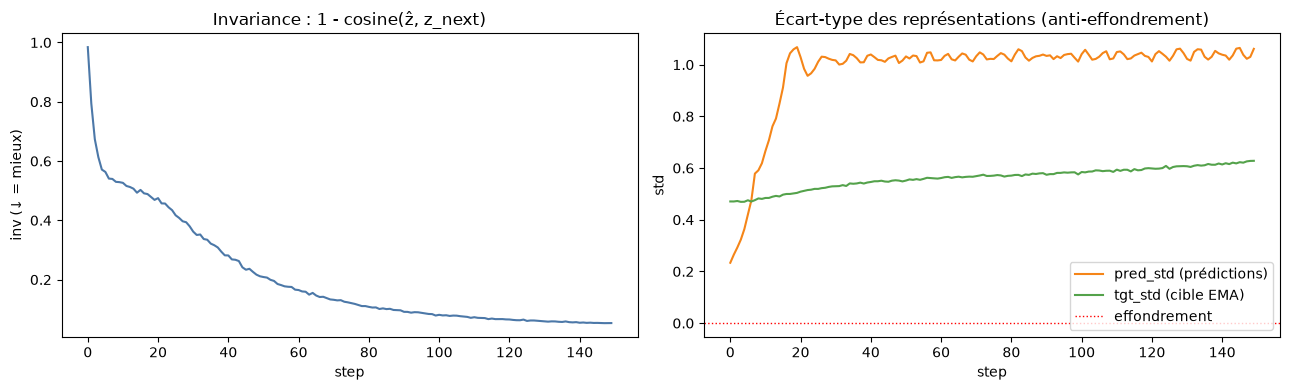

In [9]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4))
a1.plot(hist["inv"], color="#4C78A8")
a1.set(title="Invariance : 1 - cosine(ẑ, z_next)", xlabel="step", ylabel="inv (↓ = mieux)")
a2.plot(hist["pred_std"], label="pred_std (prédictions)", color="#F58518")
a2.plot(hist["tgt_std"], label="tgt_std (cible EMA)", color="#54A24B")
a2.axhline(0, color="red", ls=":", lw=1, label="effondrement")
a2.set(title="Écart-type des représentations (anti-effondrement)", xlabel="step", ylabel="std")
a2.legend()
plt.tight_layout(); plt.show()

## Bilan

L'architecture tourne : la passe avant produit les bonnes représentations, la perte se décompose comme prévu, et le contrôle montre une invariance qui baisse **sans** effondrement (`pred_std` reste franchement positif).

### Prochaine étape (à cadrer ensemble)
L'**entraînement complet** + l'**évaluation POC** :
- boucle d'entraînement sur plusieurs epochs, suivi des métriques d'effondrement ;
- **retrieval** : la représentation prédite `ẑ` retrouve-t-elle les films du vrai prochain chunk (Recall@K, rang médian) ?
- **probe de contenu** : l'espace latent reflète-t-il genres / genome (R², clustering) ?

C'est cette évaluation qui dira si le JEPA *comprend* réellement les trajectoires — ou s'il a trouvé un raccourci.